# Importação de Bibliotecas

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregamento do Dataset

In [67]:
df = pd.read_csv('../data/data.csv')

# Visualizando as 5 primeiras linhas

In [68]:
df.head()

,area_m2,quartos,banheiros,vagas,bairro,idade_anos,piscina,preco
0,142,5,1,3,Jardins,38,0,1478740
1,146,2,3,2,Jardins,19,0,1385017
2,111,4,3,1,Vila Madalena,4,0,1303994
3,228,2,1,1,Jardins,0,0,1568554
4,60,3,1,3,Vila Madalena,29,0,795241


# Informações Gerais do Dataset

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   area_m2     300 non-null    int64 
 1   quartos     300 non-null    int64 
 2   banheiros   300 non-null    int64 
 3   vagas       300 non-null    int64 
 4   bairro      300 non-null    object
 5   idade_anos  300 non-null    int64 
 6   piscina     300 non-null    int64 
 7   preco       300 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 18.9+ KB


# Estatísticas Descritivas do Dataset 

In [70]:
df.describe()

,area_m2,quartos,banheiros,vagas,idade_anos,piscina,preco
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,174.216667,3.083333,2.400000,1.466667,24.253333,0.280000,1.284183e+06
std,73.157157,1.482243,1.075728,1.110405,14.418117,0.449749,3.783321e+05
min,41.000000,1.000000,1.000000,0.000000,0.000000,0.000000,3.229010e+05
25%,103.500000,2.000000,1.000000,0.000000,12.000000,0.000000,1.017161e+06
50%,177.000000,3.000000,2.000000,1.000000,24.500000,0.000000,1.272313e+06
75%,231.500000,4.000000,3.000000,2.000000,36.000000,1.000000,1.556875e+06
max,299.000000,5.000000,4.000000,3.000000,49.000000,1.000000,2.203984e+06


# Verificação de Valores Nulos

In [71]:
df.isnull().sum()

area_m2       0
quartos       0
banheiros     0
vagas         0
bairro        0
idade_anos    0
piscina       0
preco         0
dtype: int64

# Número de linhas e de colunas

In [72]:
print(f'Número de linhas: {df.shape[0]}. Número de colunas: {df.shape[1]}')

Número de linhas: 300. Número de colunas: 8


# Paleta de cores

In [73]:
paleta = sns.color_palette('tab10')

# Como os preços dos imóveis estão distribuídos no dataset?

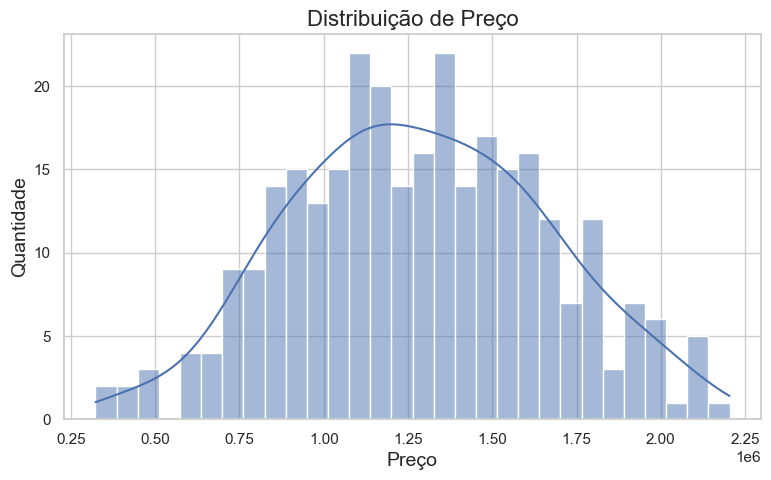

In [74]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.histplot(data=df['preco'], kde=True, bins=30)
ax.set_title('Distribuição de Preço', fontsize=16)
ax.set_xlabel('Preço', fontsize=14)
ax.set_ylabel('Quantidade', fontsize=14)

plt.show()

# Existem outliers na váriavel preço e como os valores estão dispersos?

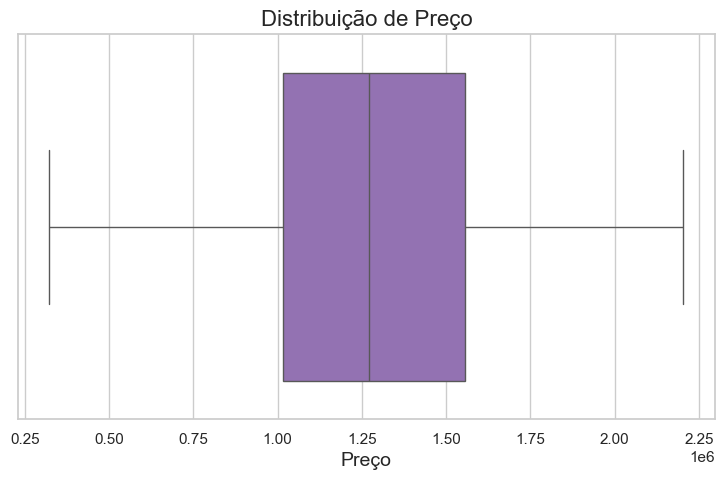

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.boxplot(x=df['preco'], color=paleta[4])
ax.set_title('Distribuição de Preço', fontsize=16)
ax.set_xlabel('Preço', fontsize=14)

plt.show()

# Quais váriaveis tem maior influência sobre o preço do imóvel?

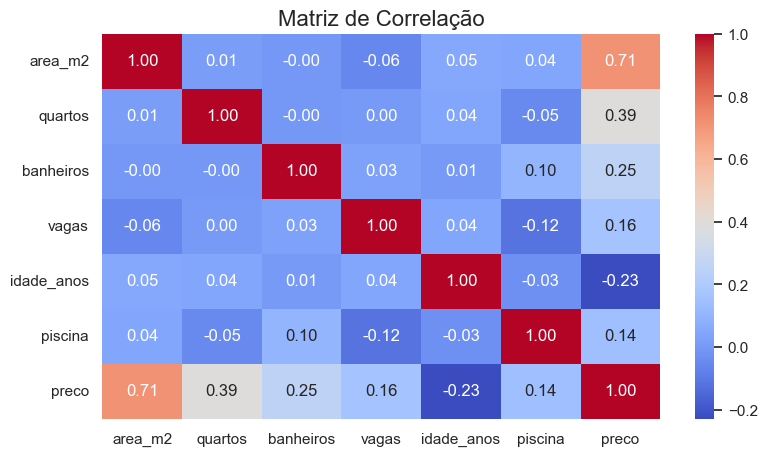

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
ax.set_title('Matriz de Correlação', fontsize=16)

plt.show()

# A área e o bairro são suficientes para explicar a variação do preço dos imóveis?

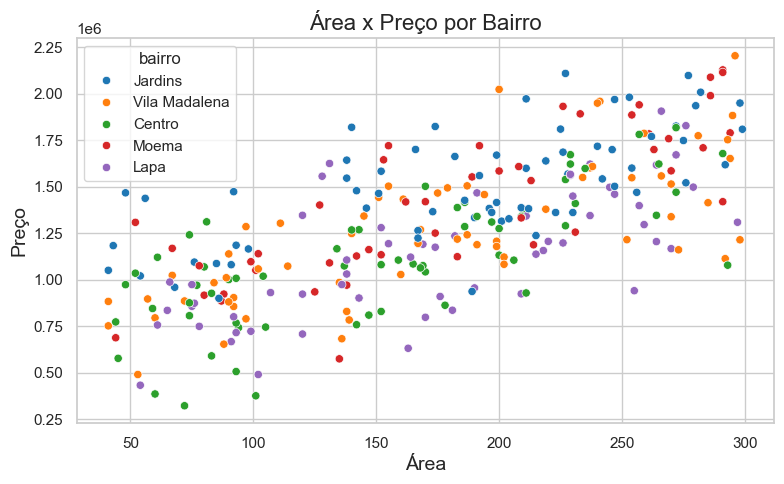

In [77]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.scatterplot(data=df, x='area_m2', y='preco', hue='bairro', palette='tab10')
ax.set_title('Área x Preço por Bairro', fontsize=16)
ax.set_xlabel('Área', fontsize=14)
ax.set_ylabel('Preço', fontsize=14)

plt.show()

# Qual o preço médio de cada bairro?

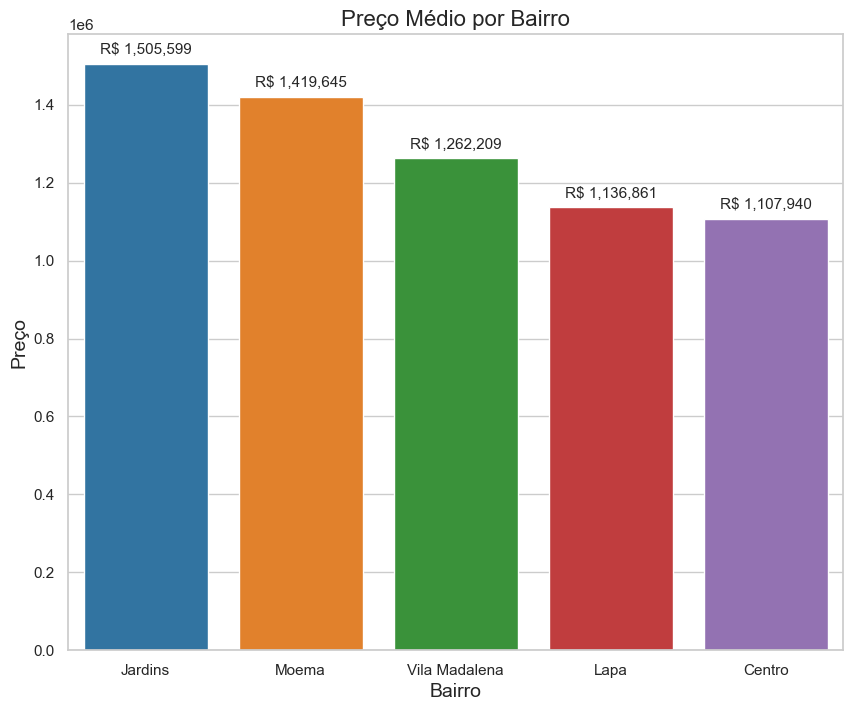

In [78]:
preco_medio = df.groupby('bairro', as_index=False)['preco'].mean().sort_values(by='preco', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(data=preco_medio, x='bairro', y='preco', palette='tab10', hue='bairro')
ax.set_title('Preço Médio por Bairro', fontsize=16)
ax.set_xlabel('Bairro', fontsize=14)
ax.set_ylabel('Preço', fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt='R$ {:,.0f}', fontsize=11, padding=5)

plt.show()

# Pré-processamento

In [79]:
df_ml = df.copy()

df_ml = df_ml.drop_duplicates()
df_ml = df_ml.dropna()

le = LabelEncoder()
df_ml['bairro'] = le.fit_transform(df_ml['bairro'])

X = df_ml.drop('preco', axis=1)
y = df_ml['preco']

print('Features: ', X.columns.tolist())
print('Shape X:', X.shape)

Features:  ['area_m2', 'quartos', 'banheiros', 'vagas', 'bairro', 'idade_anos', 'piscina']
Shape X: (300, 7)


# Divisão treino/teste

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (240, 7) | Teste: (60, 7)


# Treinar os Modelos

In [81]:
modelos = {
    'Linear Regression':  (LinearRegression(),                                              X_train_s, X_test_s),
    'Ridge Regression':   (Ridge(alpha=10),                                                 X_train_s, X_test_s),
    'Random Forest':      (RandomForestRegressor(n_estimators=100, random_state=42),        X_train,   X_test),
    'Gradient Boosting':  (GradientBoostingRegressor(n_estimators=100, random_state=42),    X_train,   X_test),
}

resultados = {}

for nome, (modelo, X_tr, X_te) in modelos.items():
    modelo.fit(X_tr, y_train)
    pred = modelo.predict(X_te)
    resultados[nome] = {
        'MAE': round(mean_absolute_error(y_test, pred), 2),
        'RMSE': round(mean_squared_error(y_test, pred) ** 0.5, 2),
        'R²': round(r2_score(y_test, pred), 4),
    }

resultado_df = pd.DataFrame(resultados).T
print(resultado_df)

                         MAE       RMSE      R²
Linear Regression  121702.93  139874.90  0.8692
Ridge Regression   123088.04  141450.70  0.8663
Random Forest      129839.92  162008.20  0.8246
Gradient Boosting   86535.62  106201.01  0.9246


# Comparar os Modelos

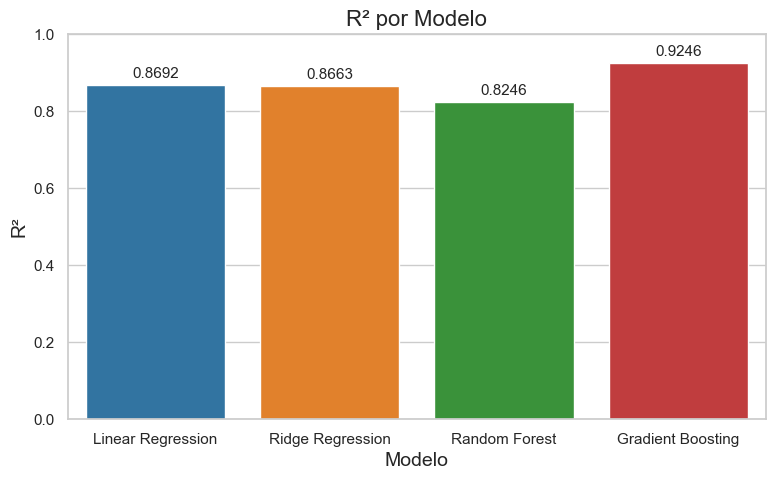

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(x=resultado_df.index, y=resultado_df['R²'], palette='tab10', hue=resultado_df.index)
ax.set_title('R² por Modelo', fontsize=16)
ax.set_xlabel('Modelo', fontsize=14)
ax.set_ylabel('R²', fontsize=14)
ax.set_ylim(0, 1.0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=11, padding=3)

plt.show()

# Feature Importance

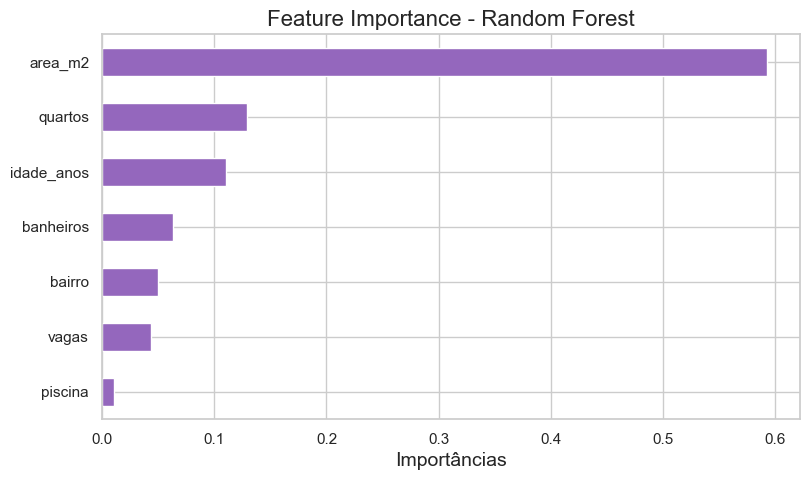

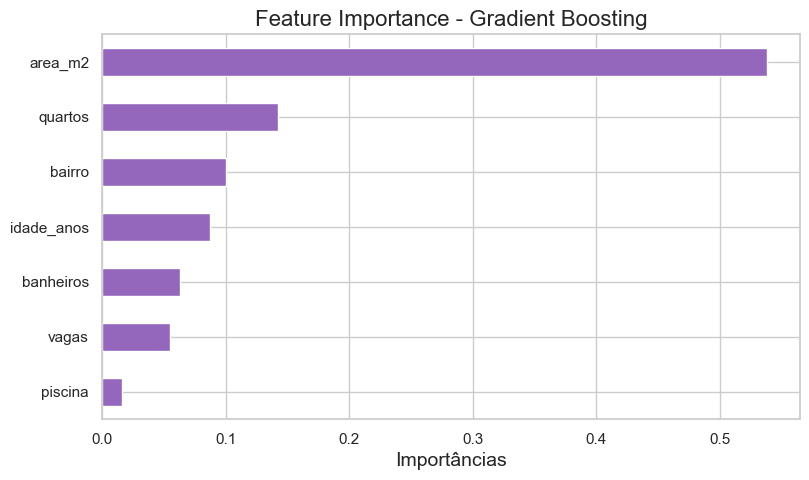

In [83]:
for nome in ['Random Forest', 'Gradient Boosting']:
    modelo = modelos[nome][0]
    importancias = pd.Series(
        modelo.feature_importances_, index=X.columns
    ).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    importancias.plot(kind='barh', ax=ax, color=paleta[4])
    ax.set_title(f'Feature Importance - {nome}', fontsize=16)
    ax.set_xlabel('Importâncias', fontsize=14)

    plt.show()